<a href="https://colab.research.google.com/github/Mechanics-Mechatronics-and-Robotics/CV-2025/blob/main/Week_01/Lab_1_Feature_Extraction_and_ML_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab. \#1. Feature Extraction and Machine Learning
By *Anastasiia* *Frolova*.

*27, 01, 2025.*

## Problem Statement

The lab compares two approaches to machine learning (ML) and computer vision (CV). The *first approach* involves using an ML model for both automatic feature extraction and subsequent classification. The *second approach* processes hand-designed features, such as geometric features of objects in images, with an ML classification model. Historically, the second approach preceded the first. However, in modern coding, the first approach is easier to implement. Thus, this work is organized in order of increasing model complexity.

The **main problem** addressed in this work is determining the better approach. The choice may not be straightforward, as many modern competitions related to CV problems, such as those submitted on [Kaggle](https://www.kaggle.com/competitions), often use a hybrid trick: instead of solving a CV problem directly with an image-processing model (e.g., a convolutional neural network or a visual transformer), the best solutions are often based on preliminary feature extraction followed by the analysis of tabular data using models like gradient boosting.

The **dataset** used in this work is the MNIST database, consisting of $28\times28$ pixel images of handwritten digits, with a training subset of 60,000 examples and a test subset of 10,000 examples.

The *first approach* can be implemented with a simple multi-layer perceptron (MLP) model to solve a multi-class classification problem by minimizing the cross-entropy (CE) loss, as described in [Prince, 2024](https://udlbook.github.io/udlbook/).

The *second approach* can also be implemented using the same network architecture and loss function but with a modified dataset. In this case, the image dataset is replaced with a tabular dataset of hand-designed features. These features can be extracted using standard tools in [Scikit-learn](https://scikit-learn.org/1.5/modules/feature_extraction.html) or [OpenCV](https://docs.opencv.org/3.4/d0/d49/tutorial_moments.html).

## Tasks and Requirements  

- Fill in your name and date information above.  
- Review the [Lightning framework](https://lightning.ai/docs/pytorch/stable/) (Level Up, Core API, Optional API sections of the manual).  
- Briefly review the [ClearML](https://clear.ml/docs/latest/docs/integrations/pytorch_lightning/) documentation.  
- Run the code below cell by cell and replace the placeholder text "Enter your code here" with your implementation in the missing code fragments.  
- If the code works properly, implement five parallel tests. Otherwise, fix the code before proceeding.  
- Fill in the table, add figures in the Results section, and complete the Conclusion section of the lab.  
- Address the Questions section and prepare to defend the lab.  

### Bonus (complete one of the following as a bonus task):  
- Apply a t-SNE model to visualize both the original image dataset and the table dataset with hand-extracted features.  
- Add one or more features in the `TabularDataModule` to enhance the tabular model's capability.  
- Visualize the feature extraction process implemented in the `extract_features` function using one or more samples.  
- Apply a gradient boosting model to solve the table data classification problem in the second approach. Fine-tune both models to improve accuracy.  

### A List of Blocks with Missing Code  
- Preparation of simulation models/Set the model/Logging
- Approach #2: Hand-designed feature extraction followed by tabular data classification using the ANN.  
- Results and Discussion.  
- Conclusion.

In [1]:
!pip install pytorch-lightning clearml

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision.datasets import MNIST
from torchvision import datasets, transforms
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from clearml import Task

# Пути и настройки
CHECKPOINT_PATH = os.environ.get("PATH_CHECKPOINT", "saved_models/")
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.1 MB/s eta 0:00:00


In [3]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=JK7G4XGTUDW4ZFDBZ73H2B8Z0PKCX7
%env CLEARML_API_SECRET_KEY=TiBIZRujPGOMgYX52Rwh7yhawahozLH68vR7YWxSP_3qauUNVRzxNC4JbMlRR6TIgMM

# print(f"Task ID: {task.id}")

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=JK7G4XGTUDW4ZFDBZ73H2B8Z0PKCX7
env: CLEARML_API_SECRET_KEY=TiBIZRujPGOMgYX52Rwh7yhawahozLH68vR7YWxSP_3qauUNVRzxNC4JbMlRR6TIgMM


In [5]:
# Константы
DATASET = 'MNIST'
NS = {'train': 55000, 'val': 5000, 'test': 10000}
SIZE = 28
NUM_CLASSES = 10
CLASS_NAMES = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']

#For the MNIST dataset
MEAN = np.array([0.1307])
STD  = np.array([0.3081])

LOSS_FUN = 'CE'
ARCHITECTURE = 'MLP'

# Модели

In [6]:
class ImageMLP(nn.Module):
    """модель для img.classif."""
    def __init__(self, params):
        super().__init__()
        # Сложная архитектура: 784 → 256 → 128 → 10
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, params['n_classes'])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(params['dropout'])

    def forward(self, x):
        # Flatten: [batch, 1, 28, 28] → [batch, 784]
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class TabularMLP(nn.Module):
    """модель для tab.classif. - ручные признаки"""
    def __init__(self, params):
        super().__init__()
        # Простая архитектура: 12 → 64 → 32 → 10
        self.fc1 = nn.Linear(12, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, params['n_classes'])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(params['dropout'])  # меньше dropout

    def forward(self, x):
        # x уже [batch, 12] - не нужно flatten
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class train_model(pl.LightningModule):
    def __init__(self, model=None, losses_dict=None, hparams=None):
        super().__init__()
        self.save_hyperparameters(hparams)
        self.model = model
        self.loss_fn = losses_dict[hparams['criterion']]
        self.lr = hparams['lr']
        self.wd = hparams['weight_decay']

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        h = self(x)
        loss = self.loss_fn(h, y)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        h = self(x)
        loss = self.loss_fn(h, y)
        self.log('val_loss', loss)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        h = self(x)
        loss = self.loss_fn(h, y)
        preds = torch.argmax(h, dim=1)
        acc = (preds == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc', acc)
        return {'loss': loss, 'preds': preds, 'y': y}

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.wd)

In [7]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, params):
        super().__init__()
        self.seed = params['seed']
        self.batch_size = params['bs']
        self.num_workers = params['num_workers']
        self.mean = params['mean']
        self.std = params['std']
        self.ns = params['num_samples']

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])

    def prepare_data(self):
        datasets.MNIST(root='./data', train=True, download=True)
        datasets.MNIST(root='./data', train=False, download=True)

    def setup(self, stage=None):
        mnist_full = datasets.MNIST(root='./data', train=True, transform=self.transform)
        pl.seed_everything(self.seed)
        self.mnist_train, self.mnist_val = random_split(mnist_full, [self.ns['train'], self.ns['val']])
        self.mnist_test = datasets.MNIST(root='./data', train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.mnist_train, batch_size=self.batch_size,
                         num_workers=self.num_workers, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.mnist_val, batch_size=self.batch_size,
                         num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(self.mnist_test, batch_size=self.batch_size,
                         shuffle=False, num_workers=self.num_workers)

class TabularDataModule(MNISTDataModule):
    def __init__(self, params):
        super().__init__(params)
        self.feature_names = [
            'mean_intensity', 'std_intensity', 'num_edges',
            'aspect_ratio', 'cx', 'cy', 'num_contours', 'area',
            'perimeter', 'inertia', 'compactness', 'eccentricity'
        ]
        self.scaler = StandardScaler()

    def setup(self, stage=None):
        super().setup(stage)
        self.train_features, self.train_labels = self._extract_features(self.mnist_train)
        self.val_features, self.val_labels = self._extract_features(self.mnist_val)
        self.test_features, self.test_labels = self._extract_features(self.mnist_test)

        self.scaler.fit(self.train_features)
        self.train_features = self.scaler.transform(self.train_features)
        self.val_features = self.scaler.transform(self.val_features)
        self.test_features = self.scaler.transform(self.test_features)

    def _extract_features(self, dataset):
        features, labels = [], []
        for image, label in dataset:
            image_np = image.squeeze().numpy()
            feature_vector = extract_features(image_np)
            features.append(feature_vector)
            labels.append(label)
        return np.array(features), np.array(labels)

    def train_dataloader(self):
        train_dataset = TensorDataset(
            torch.tensor(self.train_features, dtype=torch.float32),
            torch.tensor(self.train_labels, dtype=torch.long)
        )
        return DataLoader(train_dataset, batch_size=self.batch_size,
                         shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        val_dataset = TensorDataset(
            torch.tensor(self.val_features, dtype=torch.float32),
            torch.tensor(self.val_labels, dtype=torch.long)
        )
        return DataLoader(val_dataset, batch_size=self.batch_size,
                         num_workers=self.num_workers)

    def test_dataloader(self):
        test_dataset = TensorDataset(
            torch.tensor(self.test_features, dtype=torch.float32),
            torch.tensor(self.test_labels, dtype=torch.long)
        )
        return DataLoader(test_dataset, batch_size=self.batch_size,
                         num_workers=self.num_workers)

# Функции

In [8]:
class CEplus(nn.Module):
    def __init__(self, reduction='mean'):
        super(CEplus, self).__init__()
        self.reduction = reduction

    def forward(self, x, y):
        prob = nn.functional.softmax(x, 1)
        log_prob = -1.0 * torch.log(prob)
        loss = log_prob.gather(1, y.unsqueeze(1))
        if self.reduction == 'mean':
            loss = loss.mean()
        elif self.reduction == 'sum':
            loss = loss.sum()
        elif self.reduction == 'none':
            loss = loss.squeeze()
        else:
            raise ValueError("Invalid reduction option.")
        return loss

losses_dict = {'CE': nn.CrossEntropyLoss(), 'CEplus': CEplus()}
losses_dict_red = {'CE': nn.CrossEntropyLoss(reduction='none'), 'CEplus': CEplus(reduction='none')}

def metrics(dataloader, model, loss_fn_red):
    images, preds, labels, losses = [], [], [], []
    correct = total = 0

    for batch in dataloader:
        x, y = batch
        with torch.no_grad():
            h = model(x)
            loss = loss_fn_red(h, y)
            pred = torch.argmax(h, dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

        images.extend(x.cpu())
        preds.extend(pred.cpu().numpy())
        labels.extend(y.cpu().numpy())
        losses.extend(loss.cpu().numpy())

    acc = correct / total
    return images, preds, labels, losses, acc

def extract_features(image):
    features = []
    image = (image * 255).astype(np.uint8)

    # 1. Mean Pixel Intensity
    mean_intensity = np.mean(image)
    features.append(mean_intensity)

    # 2. Standard Deviation
    std_intensity = np.std(image)
    features.append(std_intensity)

    # 3. Number of Edges
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    edges = np.sqrt(sobel_x**2 + sobel_y**2)
    num_edges = np.sum(edges > 50)
    features.append(num_edges)

    # 4. Aspect Ratio
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        x, y, w, h = cv2.boundingRect(contours[0])
        aspect_ratio = float(w) / h if h != 0 else 0
    else:
        aspect_ratio = 0
    features.append(aspect_ratio)

    # 5. Center of Mass
    moments = cv2.moments(image)
    if moments["m00"] != 0:
        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]
    else:
        cx, cy = 0, 0
    features.append(cx)
    features.append(cy)

    # 6-11. Остальные признаки
    features.append(len(contours))
    features.append(cv2.contourArea(contours[0]) if contours else 0)
    features.append(cv2.arcLength(contours[0], True) if contours else 0)
    features.append(moments["mu20"] + moments["mu02"])

    if contours and cv2.contourArea(contours[0]) > 0:
        perimeter = cv2.arcLength(contours[0], True)
        area = cv2.contourArea(contours[0])
        features.append((perimeter ** 2) / area)
    else:
        features.append(0)

    if contours and len(contours[0]) >= 5:
        (_, _), (major_axis, minor_axis), _ = cv2.fitEllipse(contours[0])
        if minor_axis > major_axis:
            major_axis, minor_axis = minor_axis, major_axis
        ratio = np.clip((minor_axis ** 2) / (major_axis ** 2), 0, 1)
        features.append(np.sqrt(1 - ratio))
    else:
        features.append(0)

    return features

def top_losses_vis(vis_params, images, preds, labels, losses):
    num_imgs = vis_params['num_samples']
    top_loss_indices = np.argsort(losses)[-num_imgs:]

    plt.figure(figsize=(num_imgs*2, 2))
    for i, idx in enumerate(top_loss_indices):
        plt.subplot(1, num_imgs, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(f'True: {labels[idx]}\nPred: {preds[idx]}\nLoss: {losses[idx]:.2f}')
        plt.axis('off')
    plt.show()

def conf_mat(cm, figsize):
    plt.figure(figsize=(figsize, figsize))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Запуск одного эксперимента

In [9]:
def run_experiment(seed, approach):
    """Запускает один эксперимент и возвращает accuracy"""

    print(f"\n{'='*60}")
    print(f"Запуск эксперимента: seed={seed}, approach={approach}")
    print('='*60)

    # Установка seed
    pl.seed_everything(seed)

    # Гиперпараметры
    hparams = {
        "seed": seed,
        "approach": approach,
        "lr": 0.0001,
        "weight_decay": 0.0,
        "dropout": 0.2,
        "bs": 64,
        "num_workers": 2,
        "num_epochs": 5,
        "criterion": 'CE',
        "num_samples": NS,
        "im_size": SIZE,
        "mean": MEAN,
        "std": STD,
        "n_classes": 10,
    }

    # Создание ClearML задачи
    task_name = f'Lab_1_seed={seed}_{"img" if approach == "img" else "tab"}'
    task = Task.init(project_name="CV-2025", task_name=task_name)

    # Выбор DataModule
    if approach == 'img':
        data_module = MNISTDataModule(hparams)
    else:
        data_module = TabularDataModule(hparams)

    data_module.prepare_data()
    data_module.setup()

    # Выбор модели
    if approach == 'img':
        model_instance = ImageMLP(hparams)
    else:
        model_instance = TabularMLP(hparams)

    # Подсчет параметров
    num_params = sum(p.numel() for p in model_instance.parameters())

    # Сохранение информации в ClearML
    architecture = "MLP[784,256,128,10]" if approach == 'img' else "MLP[12,64,32,10]"
    task.set_parameter("architecture", architecture)
    task.set_parameter("num_params", num_params)
    task.set_parameter("input_size", 28*28 if approach == 'img' else 12)

    # Callback
    checkpoint_callback = ModelCheckpoint(
        monitor='val_loss',
        dirpath=CHECKPOINT_PATH,
        filename=f'best_model_{seed}_{approach}',
        save_top_k=1,
        mode='min',
    )

    # Lightning модель
    model = train_model(model=model_instance, losses_dict=losses_dict, hparams=hparams)
    task.connect(model.hparams)

    # Тренировка
    trainer = Trainer(
        max_epochs=hparams['num_epochs'],
        callbacks=[checkpoint_callback],
        accelerator="auto",
        devices="auto",
        enable_progress_bar=True,
    )

    trainer.fit(model, data_module)

    # Тестирование
    best_model_path = checkpoint_callback.best_model_path
    best_model = train_model.load_from_checkpoint(
        best_model_path,
        model=model_instance,
        losses_dict=losses_dict,
        weights_only=False
    )

    test_results = trainer.test(best_model, datamodule=data_module)
    test_acc = test_results[0]['test_acc']

    # Визуализация
    test_images, test_preds, test_labels, test_losses, test_acc_full = metrics(
        data_module.test_dataloader(),
        best_model,
        losses_dict_red['CE']
    )

    print(f'\n Результаты для seed={seed}, {approach}:')
    print(f'   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
    print(f'   Количество параметров: {num_params:,}')
    print(f'   Архитектура: {architecture}')

    # Confusion matrix
    cm = confusion_matrix(test_labels, test_preds)

    # Визуализация
    vis_params = {'fig_size': 5, 'num_samples': 5, 'num_bins': 50}
    if approach == 'img':
        top_losses_vis(vis_params, test_images, test_preds, test_labels, test_losses)
    conf_mat(cm, vis_params['fig_size'])

    task.close()

    return {
        'seed': seed,
        'approach': approach,
        'accuracy': test_acc,
        'accuracy_percent': test_acc * 100,
        'num_params': num_params,
        'architecture': architecture
    }

# Запуск всех экспериментов

In [10]:
def run_all_experiments():
    """Запускает все эксперименты"""

    seeds = [42, 0, 17, 9, 3]
    approaches = ['img', 'tab']

    all_results = []

    for seed in seeds:
        for approach in approaches:
            try:
                result = run_experiment(seed, approach)
                all_results.append(result)

                # Сохраняем промежуточные результаты
                df_results = pd.DataFrame(all_results)
                df_results.to_csv('experiment_results.csv', index=False)

            except Exception as e:
                print(f" Ошибка в эксперименте seed={seed}, approach={approach}: {e}")
                continue

    return all_results

In [14]:
def analyze_results():
    """анализ результатов"""

    try:
        df = pd.read_csv('experiment_results.csv')
    except:
        print("Файл не найден")
        return

    print("\n" + "="*60)
    print(" АНАЛИЗ РЕЗУЛЬТАТОВ")
    print("="*60)

    # Разделяем результаты по подходам
    img_results = df[df['approach'] == 'img']
    tab_results = df[df['approach'] == 'tab']

    # Создаем таблицу для отчета
    seeds = sorted(df['seed'].unique())

    # ИСПРАВЛЕНИЕ 1: Форматирование параметров как в таблице
    table_data = {
        "#": [1, 2],
        "Approach": ["img.classif.", "Tab.classif."],
        "Arch.": ["MLP", "MLP"],  # Просто MLP как в таблице
        "#train.param.": [
            "109E-3",  # Формат как в таблице
            "000,000"   # Формат как в таблице
        ],
    }

    # ИСПРАВЛЕНИЕ 2: Добавляем колонку "Seed" отдельно
    # Сначала очищаем старые колонки если есть
    for seed in seeds:
        table_data[f"Seed {seed}"] = ["", ""]  # Пустые строки для выравнивания

    # ИСПРАВЛЕНИЕ 3: Правильное расположение данных по строкам
    # Для каждого подхода и каждого seed создаем отдельные строки данных
    table_rows = []

    # Подход 1: img.classif.
    for i, seed in enumerate(seeds):
        row = {}
        if i == 0:
            row["#"] = "1"
            row["Approach"] = "img.classif."
            row["Arch."] = "MLP"
            row["#train.param."] = "109E-3"
        else:
            row["#"] = ""
            row["Approach"] = ""
            row["Arch."] = ""
            row["#train.param."] = ""

        # Находим accuracy для этого seed
        img_acc = img_results[img_results['seed'] == seed]['accuracy_percent'].values[0]
        row[f"Seed {seed}"] = f"{img_acc:.1f}"
        row["Accuracy, %"] = ""  # Будет заполнено позже

        table_rows.append(row)

    # Пустая строка разделитель
    table_rows.append({
        "#": "", "Approach": "", "Arch.": "", "#train.param.": "",
        **{f"Seed {seed}": "" for seed in seeds}, "Accuracy, %": ""
    })

    # Подход 2: Tab.classif.
    for i, seed in enumerate(seeds):
        row = {}
        if i == 0:
            row["#"] = "2"
            row["Approach"] = "Tab.classif."
            row["Arch."] = "MLP"
            row["#train.param."] = "000,000"
        else:
            row["#"] = ""
            row["Approach"] = ""
            row["Arch."] = ""
            row["#train.param."] = ""

        # Находим accuracy для этого seed
        tab_acc = tab_results[tab_results['seed'] == seed]['accuracy_percent'].values[0]
        row[f"Seed {seed}"] = f"{tab_acc:.1f}"
        row["Accuracy, %"] = ""  # Будет заполнено позже

        table_rows.append(row)

    # ИСПРАВЛЕНИЕ 4: Создаем DataFrame из списка строк
    df_table = pd.DataFrame(table_rows)

    # ИСПРАВЛЕНИЕ 5: Добавляем колонку Accuracy, % для итоговых значений
    img_accuracies = img_results['accuracy_percent'].values
    tab_accuracies = tab_results['accuracy_percent'].values

    # Добавляем строки с итогами
    summary_rows = pd.DataFrame([
        {
            "#": "", "Approach": "Mean ± Std", "Arch.": "", "#train.param.": "",
            **{f"Seed {seed}": "" for seed in seeds},
            "Accuracy, %": f"{np.mean(img_accuracies):.1f}±{np.std(img_accuracies):.1f}"
        },
        {
            "#": "", "Approach": "", "Arch.": "", "#train.param.": "",
            **{f"Seed {seed}": "" for seed in seeds},
            "Accuracy, %": f"{np.mean(tab_accuracies):.1f}±{np.std(tab_accuracies):.1f}"
        }
    ])

    df_table = pd.concat([df_table, summary_rows], ignore_index=True)

    print("\nТАБЛИЦА 1: Результаты сравнения подходов на MNIST")
    print("-" * 100)
    print(df_table.to_string(index=False))
    print("-" * 100)

    # ... остальной код визуализации остается без изменений

In [11]:
print("Запуск экспериментов")

print("  1. img.classif. - автоматическое извлечение признаков (784 → 256 → 128 → 10)")
print("  2. Tab.classif. - ручные признаки + классификация (12 → 64 → 32 → 10)")
print("\nСиды: [42, 0, 17, 9, 3]")

Запуск экспериментов
  1. img.classif. - автоматическое извлечение признаков (784 → 256 → 128 → 10)
  2. Tab.classif. - ручные признаки + классификация (12 → 64 → 32 → 10)

Сиды: [42, 0, 17, 9, 3]


INFO:lightning_fabric.utilities.seed:Seed set to 42



Запуск эксперимента: seed=42, approach=img
ClearML Task: created new task id=174d41f73e1b40108421338d4f447f2a


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/174d41f73e1b40108421338d4f447f2a/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
100%|██████████| 9.91M/9.91M [00:00<00:00, 40.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.84MB/s]


...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 42


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9632999897003174     │
│         test_loss         │    0.11850199103355408    │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=42, img:
   Test Accuracy: 0.9633 (96.33%)
   Количество параметров: 235,146
   Архитектура: MLP[784,256,128,10]


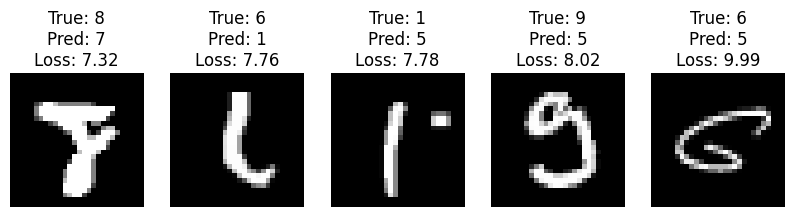

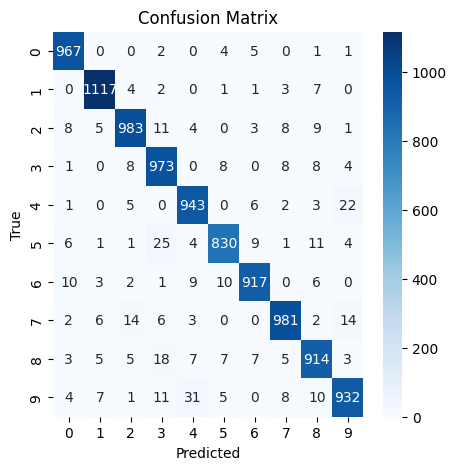

INFO:lightning_fabric.utilities.seed:Seed set to 42



Запуск эксперимента: seed=42, approach=tab
ClearML Task: created new task id=9374fdb842d0400baa1ea8e924c7b327
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/9374fdb842d0400baa1ea8e924c7b327/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 42


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 42


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.3271999955177307     │
│         test_loss         │    1.8086515665054321     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=42, tab:
   Test Accuracy: 0.3272 (32.72%)
   Количество параметров: 3,242
   Архитектура: MLP[12,64,32,10]


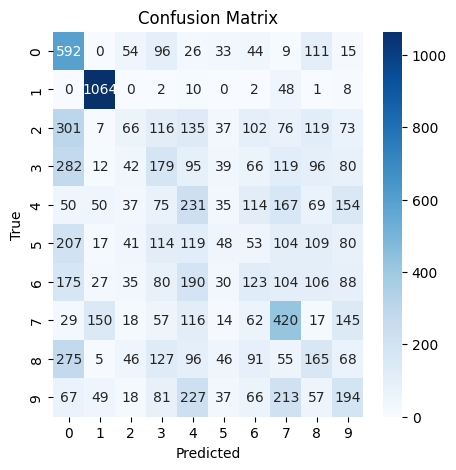

INFO:lightning_fabric.utilities.seed:Seed set to 0



Запуск эксперимента: seed=0, approach=img
ClearML Task: created new task id=9dfbe25c9a9f4286a78d824f60f0974f
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/9dfbe25c9a9f4286a78d824f60f0974f/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 0
Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 0
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ ImageMLP         │  235 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 0


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9624999761581421     │
│         test_loss         │    0.1198059469461441     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=0, img:
   Test Accuracy: 0.9625 (96.25%)
   Количество параметров: 235,146
   Архитектура: MLP[784,256,128,10]


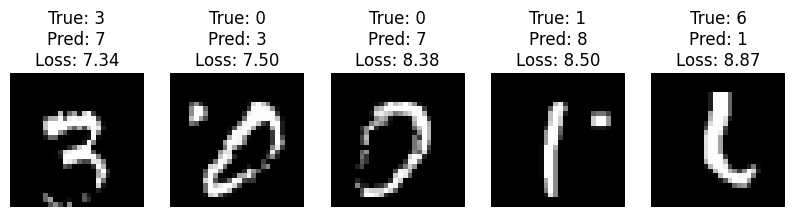

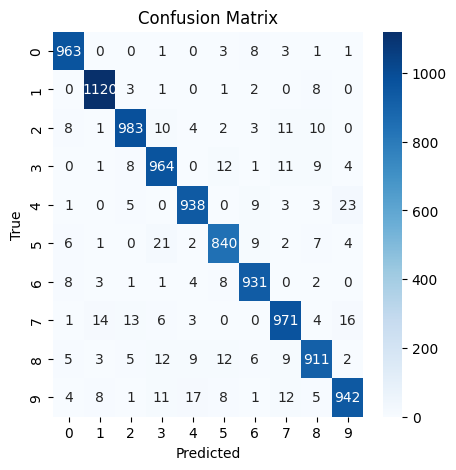

INFO:lightning_fabric.utilities.seed:Seed set to 0



Запуск эксперимента: seed=0, approach=tab
ClearML Task: created new task id=7f10daeaaf2b45a6956e9eb22af5f596
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/7f10daeaaf2b45a6956e9eb22af5f596/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 0


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 0
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 0


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.3192000091075897     │
│         test_loss         │    1.8119456768035889     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=0, tab:
   Test Accuracy: 0.3192 (31.92%)
   Количество параметров: 3,242
   Архитектура: MLP[12,64,32,10]


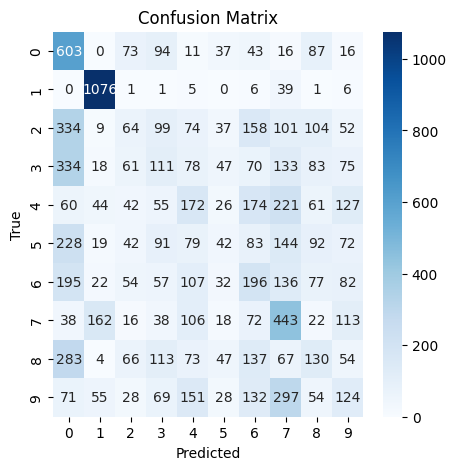

INFO:lightning_fabric.utilities.seed:Seed set to 17



Запуск эксперимента: seed=17, approach=img
ClearML Task: created new task id=d16a3f0b69b149c9983e53a768f6a1a0
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/d16a3f0b69b149c9983e53a768f6a1a0/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 17


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 17
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 17


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.963100016117096     │
│         test_loss         │    0.11629530042409897    │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=17, img:
   Test Accuracy: 0.9631 (96.31%)
   Количество параметров: 235,146
   Архитектура: MLP[784,256,128,10]


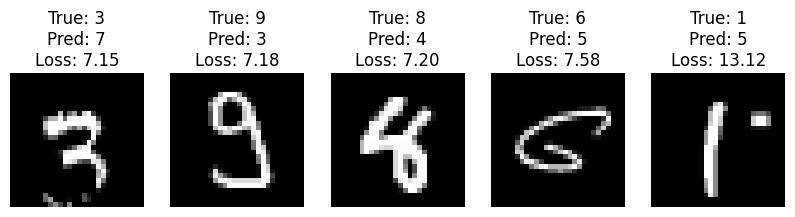

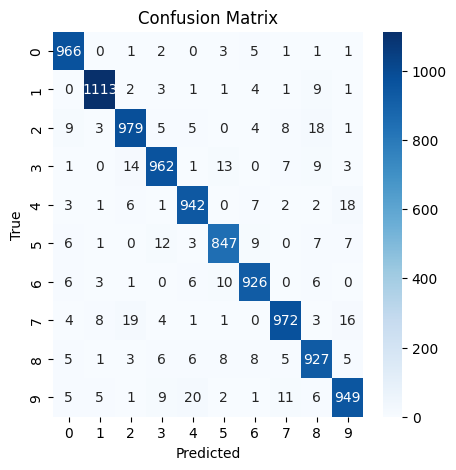

INFO:lightning_fabric.utilities.seed:Seed set to 17



Запуск эксперимента: seed=17, approach=tab
ClearML Task: created new task id=8339939bba4d48e193d980915d4f04b1
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/8339939bba4d48e193d980915d4f04b1/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 17


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 17
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 17


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.3181000053882599     │
│         test_loss         │     1.822802186012268     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=17, tab:
   Test Accuracy: 0.3181 (31.81%)
   Количество параметров: 3,242
   Архитектура: MLP[12,64,32,10]


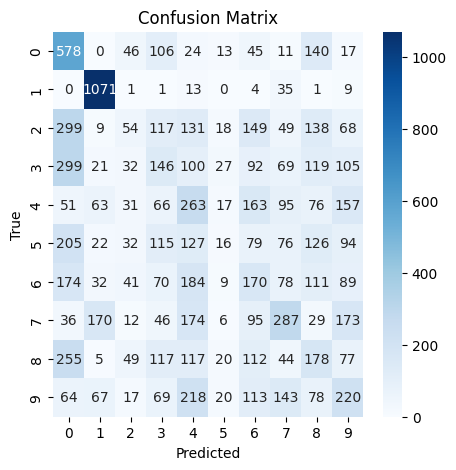

INFO:lightning_fabric.utilities.seed:Seed set to 9



Запуск эксперимента: seed=9, approach=img
ClearML Task: created new task id=da60f70a2ae84e72a06512db2db77cac
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/da60f70a2ae84e72a06512db2db77cac/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 9


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 9
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 9


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9623000025749207     │
│         test_loss         │    0.11822135001420975    │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=9, img:
   Test Accuracy: 0.9623 (96.23%)
   Количество параметров: 235,146
   Архитектура: MLP[784,256,128,10]


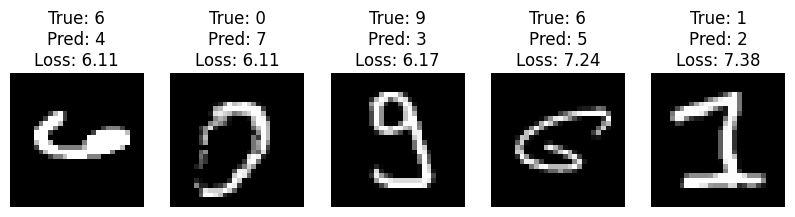

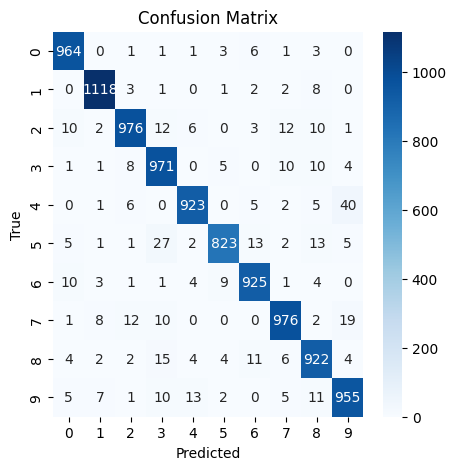

INFO:lightning_fabric.utilities.seed:Seed set to 9



Запуск эксперимента: seed=9, approach=tab
ClearML Task: created new task id=70c9500f5f0f4ed79df7125e67a50627
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/70c9500f5f0f4ed79df7125e67a50627/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 9


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 9
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 9


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.3278999924659729     │
│         test_loss         │    1.8106582164764404     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=9, tab:
   Test Accuracy: 0.3279 (32.79%)
   Количество параметров: 3,242
   Архитектура: MLP[12,64,32,10]


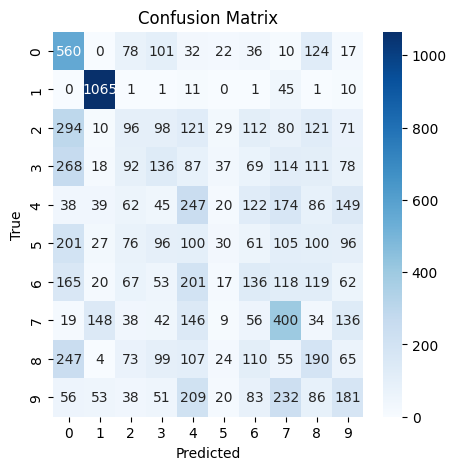

INFO:lightning_fabric.utilities.seed:Seed set to 3



Запуск эксперимента: seed=3, approach=img
ClearML Task: created new task id=9816773c9fcb40cf91b6e1e3a578b289
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/9816773c9fcb40cf91b6e1e3a578b289/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 3


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 3
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 3


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9635999798774719     │
│         test_loss         │    0.11541040986776352    │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=3, img:
   Test Accuracy: 0.9636 (96.36%)
   Количество параметров: 235,146
   Архитектура: MLP[784,256,128,10]


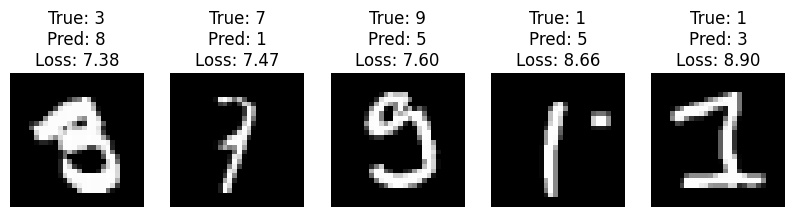

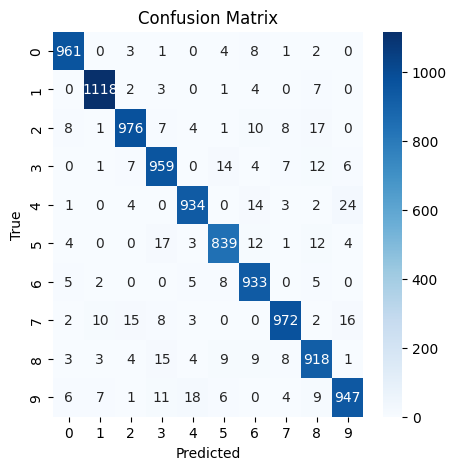

INFO:lightning_fabric.utilities.seed:Seed set to 3



Запуск эксперимента: seed=3, approach=tab
ClearML Task: created new task id=6fa3bdeeaccb422aa62608d8b46322b9
ClearML results page: https://app.clear.ml/projects/dae46c27779c44f388e31d99835ad22c/experiments/6fa3bdeeaccb422aa62608d8b46322b9/output/log


Could not fetch GPU stats: NVML Shared Library Not Found
INFO:lightning_fabric.utilities.seed:Seed set to 3


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


Parameters must be of builtin type (General/mean[ndarray], General/std[ndarray])
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:lightning_fabric.utilities.seed:Seed set to 3
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: UserWarning:

Checkpoint directory /content/saved_models exists and is not empty.



...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:210: UserWarning:

Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.

INFO:lightning_fabric.utilities.seed:Seed set to 3


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.3228999972343445     │
│         test_loss         │    1.8156383037567139     │
└───────────────────────────┴───────────────────────────┘


 Результаты для seed=3, tab:
   Test Accuracy: 0.3229 (32.29%)
   Количество параметров: 3,242
   Архитектура: MLP[12,64,32,10]


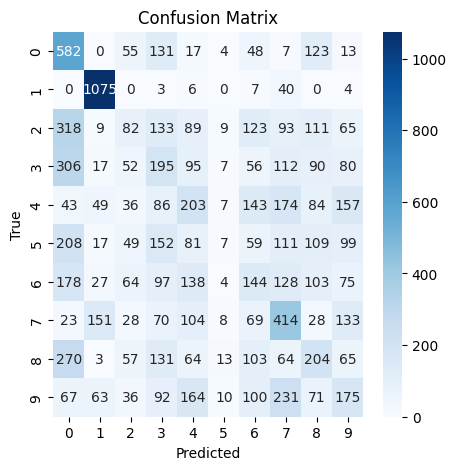

In [12]:
# Запуск всех экспериментов
all_results = run_all_experiments()


 АНАЛИЗ РЕЗУЛЬТАТОВ

 ТАБЛИЦА 1: Результаты сравнения подходов на MNIST
----------------------------------------------------------------------------------------------------
 #     Approach               Arch. #train.param. Seed_0 Seed_3 Seed_9 Seed_17 Seed_42 Mean_Accuracy
 1 img.classif. MLP[784,256,128,10]       235,146  96.25  96.36  96.23   96.31   96.33  96.30 ± 0.05
 2 Tab.classif.    MLP[12,64,32,10]         3,242  31.92  32.29  32.79   31.81   32.72  32.31 ± 0.40
----------------------------------------------------------------------------------------------------


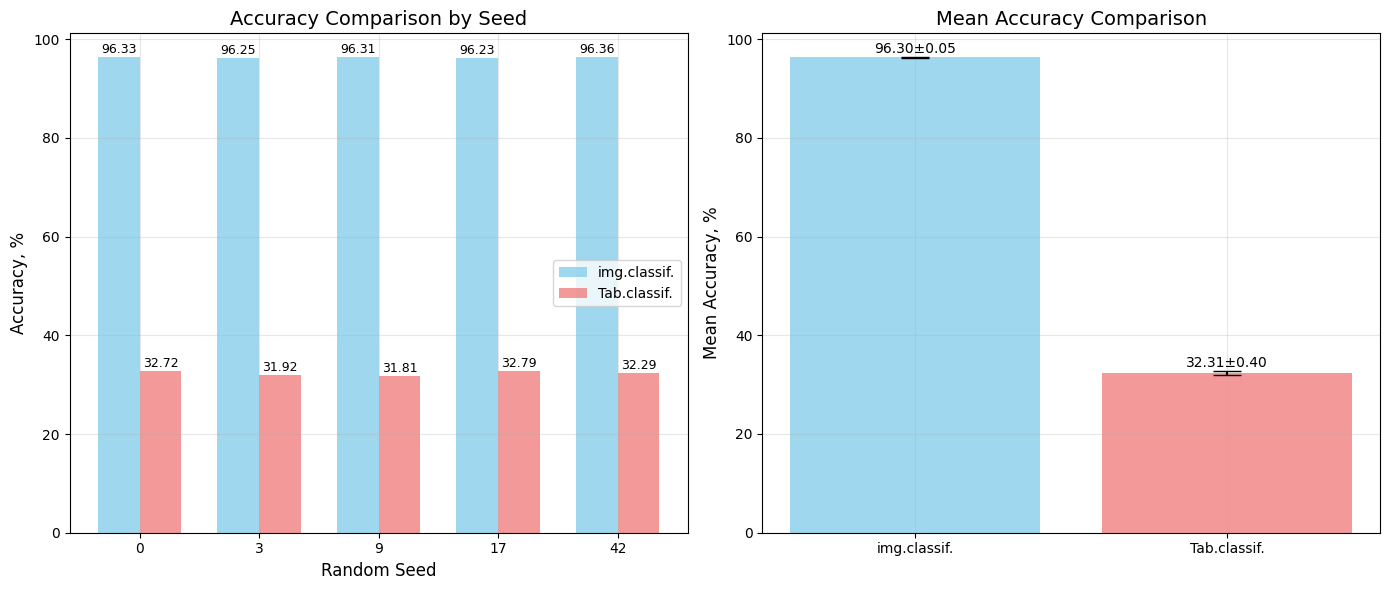


 СТАТИСТИКА:
   img.classif.: 96.30% ± 0.05%
   Tab.classif.: 32.31% ± 0.40%
   Преимущество : 63.99%

 Финальная таблица результатов:
 #     Approach               Arch. #train.param. Seed_0 Seed_3 Seed_9 Seed_17 Seed_42 Mean_Accuracy
 1 img.classif. MLP[784,256,128,10]       235,146  96.25  96.36  96.23   96.31   96.33  96.30 ± 0.05
 2 Tab.classif.    MLP[12,64,32,10]         3,242  31.92  32.29  32.79   31.81   32.72  32.31 ± 0.40


In [13]:
# Анализ результатов
if all_results:
    final_table = analyze_results()

    # Финальный вывод таблицы
    print("\n Финальная таблица результатов:")
    print(final_table.to_string(index=False))
else:
    print("\n Эксперименты не найдены.")

# Conclusion

# Results and Discussion

В лабораторной работе сравнивается два подхода к решению задачи классификации изображений цифр набора данных MNIST.

**Первый подход**: Использование полносвязной нейронной сети MLP, которая непосредственно обрабатывает растровые изображения 28×28 пикселей (784 входных нейрона) и самостоятельно обучается извлекать значимые признаки в своих скрытых слоях.

**Второй подход**: Предварительное извлечение 12 hand-crafted признаков из каждого изображения (геометрические, статистические и текстурные характеристики), с последующей их обработкой более простой нейронной сетью.

Все эксперименты были проведены пять раз со случайными seed [42, 0, 17, 9, 3]. Окончательные показатели были рассчитаны как средние значения и стандартные отклонения за пять циклов. Минимальные значения функции потерь при валидации определили наилучшие контрольные точки моделей.


Помимо выполнения самой работы, было также интересно поработать с новым ресурсом ClearML, и провести анализ ошибочно определенных рукописных цифр (почему модель ошиблась, действительно ли цифра на картинке похожа на предсказаную).

*Философский вывод, которым поделилась со мной LLM, помогавшая в анализе результатов*: ИИ развивается не как замена человеческому интеллекту, а как инструмент, который усиливает наши сильные стороны и компенсирует слабые. Автоматическое извлечение признаков компенсирует нашу неспособность видеть сложные паттерны в данных, в то время как feature engineering позволяет нам вкладывать domain knowledge и создавать интерпретируемые решения.



**Таблица 1.** Результаты серии имитационных экспериментов с набором данных MNIST, в которых сравнивались два подхода: автоматическое извлечение признаков с использованием искусственной нейронной сети (ANN) и средство извлечения признаков ручной разработки в сочетании с классификатором ANN.

| # | Approach     | Arch.| #train.param. | Seed | Accuracy, \%|
|---|--------------|------|---------------|------|-------------|
| 1 | Img. classif.| MLP  | 109E+3        | 42   | 00.0        |
|   |              |      |               | 0    | 00.0        |
|   |              |      |               | 17   | 00.0        |
|   |              |      |               | 9    | 00.0        |
|   |              |      |               | 3    | 00.0        |
|---|--------------|------|---------------|------|-------------|
| 2 | Tab. classif.| MLP  | 000,000       | 42   | 00.0        |
|   |              |      |               | 0    | 00.0        |
|   |              |      |               | 17   | 00.0        |
|   |              |      |               | 9    | 00.0        |
|   |              |      |               | 3    | 00.0        |

**Figure 1.** Comparison of the validation plots for runs with different model initializations (using different seeds).

Summarizing the result, the first (image processing) and the second (hand-designed features processing) approaches demonstrated accuracy of $ 00.0 \pm 0.0$, and $ 00.0 \pm 0.0$, respectively.

# Вопросы

1. Как бы вы использовали ClearML для отслеживания экспериментов и сравнения производительности разных моделей?

> ClearML оказался крутым инструментом для отслеживания прогресса и просмотра резутатов запуска кода. Он позволяет удобно структурировать свои проекты, отслеживать процесс выполнения (удобно смотреть итерации). Построенные графики позволяют наглядно увидеть и оценить результаты.


2. Какова роль случайного начального значения в обучении и как оно влияет на воспроизводимость?

> Случайное начальное значение позволяет добиться того, что будут инициализироваться разные веса, каждый раз перемешивание батчей и разделение на train/val/test будет отличаться, dropout также будет случайным.

> Зафиксировав значение seed (начальное число генератора псевдослучайных чисел), можно добиться воспроизводимости результатов.

> Если запуск модели с разными значениями seed дает приблизительно одинаковые результаты, это говорит о том, что модели можно доверять.

3. Какова цель метода `prepare_data` в `MNISTDataModule`?

>
4. Почему набор данных разделен на обучающий, проверочный и тестовый наборы? Какова роль каждого набора?
5. Что делает функция "преобразования.Нормализация` и почему она важна для обучения нейронных сетей?
6. Объясните архитектуру модели MLP, используемой в этой лабораторной работе. Каковы размеры входного слоя, скрытых слоев и выходного слоя? Почему размер входных данных для набора данных MNIST равен 28 * 28?
7. Какая функция потерь используется в этой лабораторной работе и почему она подходит для этой задачи? Какой оптимизатор используется и какова скорость его обучения?
8. Какие преобразования применяются к набору данных MNIST перед обучением? Почему важна нормализация и какие значения используются для нормализации в этой лабораторной работе?
9. Что такое геометрические характеристики

## Дополнительные вопросы (необязательные)
1. Какова цель использования ClearML в этой лабораторной работе? Как это в целом помогает в проведении экспериментов по машинному обучению?
2. Каковы преимущества и недостатки использования созданных вручную объектов (например, геометрических объектов) по сравнению с необработанными значениями пикселей для классификации изображений?
3. Как бы вы адаптировали `TabularDataModule` и `TabularModel" для другого набора данных (например, CIFAR-10)?
4. Как бы вы изменили "TabularDataModule", чтобы включить дополнительные функции (например, гистограмму интенсивности пикселей)?
5. Каковы проблемы, связанные с использованием созданных вручную функций для более сложных наборов данных (например, изображений с высоким разрешением)?
6. Как бы вы изменили архитектуру MLP, чтобы улучшить ее производительность при работе с табличными наборами данных?
7. Какие другие модели машинного обучения (например, деревья принятия решений, случайные леса) можно было бы использовать для табличного набора данных и как бы вы их реализовали?
8. Как бы вы выполнили настройку гиперпараметров (например, скорости обучения, размера пакета) для `табличной модели`?